# GAM (Generalized Additive Model) Pipeline — Trajectory Prediction Metrics

This notebook implements a complete GAM pipeline for analysing how agent motion and scene context features affect trajectory prediction quality (ADE/FDE), including:
- Distribution checks for features and target
- Correlation analysis (linear and non-linear)
- Feature selection (removing highly correlated features)
- Log transformation of the target (if right-skewed)
- Feature standardization
- Linear GAM fitting and evaluation
- Alternative GAM setups (e.g., GammaGAM)
- Removal of non-significant features
- Refitting on selected features
- Final evaluation and comparison

## 1. Import Required Libraries

In [501]:
# Core libraries
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution checks
from scipy import stats
from scipy.stats import skew, shapiro

# Preprocessing and evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.feature_selection import mutual_info_regression

# GAM models
from pygam import LinearGAM, GammaGAM, s, f, l

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Notebook-level config constants
DATA_PATH = Path('../../results/interpretable_model/prepared_data/prepared_data_ml_ade.csv')
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log'

RANDOM_STATE = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
POOR_WELL_QUANTILE = 0.20

SAVE_DIR = Path('../../results/interpretable_model/xgboost')
PLOTS_DIR = SAVE_DIR / 'plots'
TABLES_DIR = SAVE_DIR / 'tables'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9, 'Split ratios must sum to 1.0'

print('Imports and configuration loaded.')
print(f'DATA_PATH: {DATA_PATH}')
print(f'SAVE_DIR:  {SAVE_DIR.resolve()}')

Imports and configuration loaded.
DATA_PATH: ../../results/interpretable_model/prepared_data/prepared_data_ml_ade.csv
SAVE_DIR:  /Users/zoe/Desktop/ds_practical/results/interpretable_model/xgboost


## 2. Load and Inspect the Dataset

Load the trajectory prediction evaluation metrics CSV produced by the Trajectron++ pipeline. Each row represents one agent trajectory with motion features, scene context features, and prediction error metrics.

In [502]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
print('Columns:')
print(df.columns.tolist())

display(df.head())

missing_summary = df.isna().sum().sort_values(ascending=False)
print('\nMissing values per column:')
display(missing_summary.to_frame('missing_count'))

dtype_summary = df.dtypes.astype(str).to_frame('dtype')
print('\nColumn dtypes:')
display(dtype_summary)

Dataset shape: (451, 14)
Columns:
['max_speed', 'std_speed', 'mean_acceleration', 'max_acceleration', 'path_efficiency', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_bbox_area', 'scene_bbox_width', 'scene_spatial_density', 'scene_density_VEHICLE', 'ml_ade_log']


,max_speed,std_speed,mean_acceleration,max_acceleration,path_efficiency,heading_change,has_collision,min_neighbor_distance,scene_num_agents,scene_bbox_area,scene_bbox_width,scene_spatial_density,scene_density_VEHICLE,ml_ade_log
0,1.230403,0.116722,0.056417,0.404461,84.461237,112.440745,0.0,1.013903,17.0,1160.377375,40.869190,0.014650,0.005171,0.649643
1,0.218477,0.063105,0.007725,0.311925,15.733080,941.304051,0.0,3.023524,17.0,1160.377375,40.869190,0.014650,0.005171,0.140704
2,0.383437,0.099171,0.031384,0.470005,43.684220,488.173829,0.0,1.104355,50.0,1821.083675,44.533135,0.027456,0.012630,0.388765
3,1.483624,0.190256,0.051802,0.794096,95.139840,81.155053,1.0,0.426945,16.0,1230.401053,43.391608,0.013004,0.005689,0.821990
4,0.218477,0.064457,0.010995,0.311925,27.282729,946.683531,0.0,2.796330,15.0,1057.088774,37.340273,0.014190,0.005676,0.159340



Missing values per column:


,missing_count
max_speed,0
std_speed,0
mean_acceleration,0
max_acceleration,0
path_efficiency,0
heading_change,0
has_collision,0
min_neighbor_distance,0
scene_num_agents,0
scene_bbox_area,0



Column dtypes:


,dtype
max_speed,float64
std_speed,float64
mean_acceleration,float64
max_acceleration,float64
path_efficiency,float64
heading_change,float64
has_collision,float64
min_neighbor_distance,float64
scene_num_agents,float64
scene_bbox_area,float64


In [503]:
# Data types and missing values
print("Dataset Info:")
print(f"{'='*60}")
df.info()
print(f"\n{'='*60}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   max_speed              451 non-null    float64
 1   std_speed              451 non-null    float64
 2   mean_acceleration      451 non-null    float64
 3   max_acceleration       451 non-null    float64
 4   path_efficiency        451 non-null    float64
 5   heading_change         451 non-null    float64
 6   has_collision          451 non-null    float64
 7   min_neighbor_distance  451 non-null    float64
 8   scene_num_agents       451 non-null    float64
 9   scene_bbox_area        451 non-null    float64
 10  scene_bbox_width       451 non-null    float64
 11  scene_spatial_density  451 non-null    float64
 12  scene_density_VEHICLE  451 non-null    float64
 13  ml_ade_log             451 non-null    float64
dtypes: float64(14)
memory usage: 49.5 KB


Missi

In [504]:
# Summary statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,max_speed,std_speed,mean_acceleration,max_acceleration,path_efficiency,heading_change,has_collision,min_neighbor_distance,scene_num_agents,scene_bbox_area,scene_bbox_width,scene_spatial_density,scene_density_VEHICLE,ml_ade_log
count,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000
mean,1.255228,0.139951,0.013555,0.636907,90.604206,129.101404,0.170732,2.505512,23.166297,1370.663233,40.175802,0.017466,0.005686,0.539613
std,0.503591,0.104514,0.047515,0.462872,18.840160,232.915787,0.376692,2.488479,9.019796,459.222736,5.788054,0.004751,0.002103,0.294349
min,0.000000,0.000000,-0.202674,0.000000,8.334199,0.000000,0.000000,0.416587,14.000000,776.025388,26.965117,0.009868,0.002880,0.029143
25%,1.230403,0.071290,-0.007716,0.355789,90.405945,21.576863,0.000000,0.923652,17.000000,1007.260160,36.739884,0.013504,0.003866,0.302812
50%,1.395103,0.114736,0.005237,0.545564,99.075835,45.965562,0.000000,1.219394,20.000000,1187.889506,40.145465,0.017126,0.005676,0.513600
75%,1.564261,0.183586,0.030841,0.836947,99.824145,95.159929,0.000000,3.848581,23.000000,1841.250853,44.443819,0.021330,0.007284,0.732095
max,2.048388,0.582534,0.183462,2.932473,100.000000,1266.745180,1.000000,16.176613,50.000000,2260.842272,51.971918,0.036208,0.017735,1.546444


In [505]:
if TARGET_COL is not None:
    assert TARGET_COL in df.columns, f'TARGET_COL={TARGET_COL} not found in dataset columns.'
    target_col = TARGET_COL
else:
    if 'ml_ade_log' in df.columns:
        target_col = 'ml_ade_log'
    elif 'ml_ade' in df.columns:
        target_col = 'ml_ade'
    else:
        target_col = df.columns[-1]

feature_cols = [c for c in df.columns if c != target_col]

# Keep only numeric features (prepared dataset is expected to be numeric-only)
non_numeric_features = [c for c in feature_cols if not np.issubdtype(df[c].dtype, np.number)]
if non_numeric_features:
    print('WARNING: Non-numeric features found and dropped:')
    print(non_numeric_features)
feature_cols = [c for c in feature_cols if c not in non_numeric_features]

model_df = df[feature_cols + [target_col]].dropna().copy()

X = model_df[feature_cols].to_numpy()
y = model_df[target_col].to_numpy()
row_ids = model_df.index.to_numpy()

print(f'Target column: {target_col}')
print(f'Number of features: {len(feature_cols)}')
print(f'Rows available for modeling: {len(model_df)}')
print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape: {y.shape}')

Target column: ml_ade_log
Number of features: 13
Rows available for modeling: 451
Feature matrix shape: (451, 13)
Target vector shape: (451,)


## 3. Nested Cross-Validation (Unbiased Evaluation)

Evaluate LinearGAM with nested 5×3 CV: the inner loop tunes `n_splines`, `spline_order`, and `lam`; the outer loop provides unbiased generalisation estimates.

Hyperparameter grid: 88 combinations
  n_splines:    [10, 15, 20, 25]
  spline_order: [3, 4]
  lam:          11 values in [1e-3, 1e3]
  Fold 1: n_sp=25, ord=3, lam=0.2512 → R²=0.6291  MAE=0.2475
  Fold 2: n_sp=15, ord=3, lam=1.0000 → R²=0.5057  MAE=0.2857
  Fold 3: n_sp=15, ord=3, lam=15.8489 → R²=0.6031  MAE=0.2914
  Fold 4: n_sp=15, ord=3, lam=15.8489 → R²=0.4454  MAE=0.2880
  Fold 5: n_sp=10, ord=4, lam=1.0000 → R²=0.6210  MAE=0.2617

Nested 5×3 CV Summary (LinearGAM)


,Mean,Std,95% CI (±)
R² (Train),0.6994,0.0681,0.0597
R² (Test),0.5609,0.0813,0.0713
MAE (Train),0.2310,0.0256,0.0224
MAE (Test),0.2748,0.0193,0.0169
RMSE (Train),0.3168,0.0363,0.0318
RMSE (Test),0.3802,0.0272,0.0239



Per-fold best hyperparameters:


,Fold,Best n_splines,Best spline_order,Best lam,Inner CV R²,R² (Test)
0,1,25,3,0.2512,0.5352,0.6291
1,2,15,3,1.0000,0.6257,0.5057
2,3,15,3,15.8489,0.5383,0.6031
3,4,15,3,15.8489,0.6097,0.4454
4,5,10,4,1.0000,0.5413,0.6210


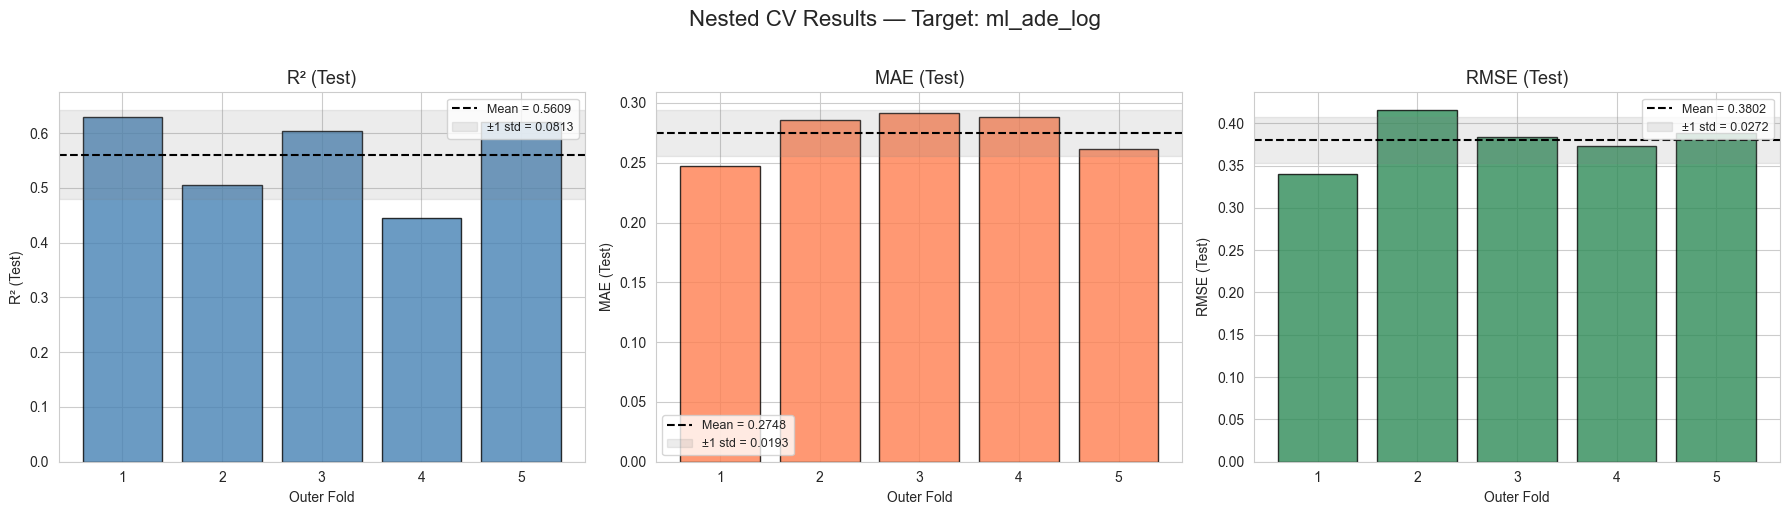


Final HP selection (3-fold CV on full data for Section 9 hold-out fit)
  n_splines:    20
  spline_order: 3
  lam:          15.8489
  CV R²:        0.5859


In [506]:
from itertools import product
from sklearn.model_selection import KFold

# ── Hyperparameter grid ──────────────────────────────────────────────────────
hp_grid = {
    "n_splines": [10, 15, 20, 25],
    "spline_order": [3, 4],
    "lam": np.logspace(-3, 3, 11),
}

n_combos = len(hp_grid["n_splines"]) * len(hp_grid["spline_order"]) * len(hp_grid["lam"])
print(f"Hyperparameter grid: {n_combos} combinations")
print(f"  n_splines:    {hp_grid['n_splines']}")
print(f"  spline_order: {hp_grid['spline_order']}")
print(f"  lam:          {len(hp_grid['lam'])} values in [1e-3, 1e3]")

# ── Nested CV: outer 5-fold for evaluation, inner 3-fold for tuning ─────────

N_INNER_FOLDS = 3
N_OUTER_FOLDS = 5
outer_kf = KFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=42)
n_feat = X.shape[1]
LOG_TRANSFORM = target_col.endswith("_log")

nested_cv_results = []

for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(outer_kf.split(X), start=1):
    X_outer_train, X_outer_test = X[outer_train_idx], X[outer_test_idx]
    y_outer_train, y_outer_test = y[outer_train_idx], y[outer_test_idx]

    # ── Inner CV: tune HPs on outer training set only ────────────────────
    inner_kf = KFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=42)
    best_inner_score = -np.inf
    best_inner_hp = {}

    for n_sp, sp_ord in product(hp_grid["n_splines"], hp_grid["spline_order"]):
        hp_terms = s(0, n_splines=n_sp, spline_order=sp_ord)
        for i in range(1, n_feat):
            hp_terms += s(i, n_splines=n_sp, spline_order=sp_ord)

        for lam_val in hp_grid["lam"]:
            inner_scores = []

            for inner_train_idx, inner_val_idx in inner_kf.split(X_outer_train):
                X_inn_tr = X_outer_train[inner_train_idx]
                X_inn_val = X_outer_train[inner_val_idx]
                y_inn_tr = y_outer_train[inner_train_idx]
                y_inn_val = y_outer_train[inner_val_idx]

                inn_scaler = StandardScaler()
                X_inn_tr_s = inn_scaler.fit_transform(X_inn_tr)
                X_inn_val_s = inn_scaler.transform(X_inn_val)

                try:
                    gam_inn = LinearGAM(hp_terms, lam=lam_val)
                    gam_inn.fit(X_inn_tr_s, y_inn_tr)
                    y_inn_pred = gam_inn.predict(X_inn_val_s)

                    if LOG_TRANSFORM:
                        sc = r2_score(np.expm1(y_inn_val), np.expm1(y_inn_pred))
                    else:
                        sc = r2_score(y_inn_val, y_inn_pred)
                    inner_scores.append(sc)
                except Exception:
                    inner_scores.append(float("-inf"))

            mean_inner = np.mean(inner_scores)
            if mean_inner > best_inner_score:
                best_inner_score = mean_inner
                best_inner_hp = {"n_splines": n_sp, "spline_order": sp_ord, "lam": lam_val}

    # ── Outer fold: refit best HPs on full outer training set ────────────
    outer_scaler = StandardScaler()
    X_outer_train_s = outer_scaler.fit_transform(X_outer_train)
    X_outer_test_s = outer_scaler.transform(X_outer_test)

    best_terms = s(0, n_splines=best_inner_hp["n_splines"],
                   spline_order=best_inner_hp["spline_order"])
    for i in range(1, n_feat):
        best_terms += s(i, n_splines=best_inner_hp["n_splines"],
                        spline_order=best_inner_hp["spline_order"])

    outer_gam = LinearGAM(best_terms, lam=best_inner_hp["lam"])
    outer_gam.fit(X_outer_train_s, y_outer_train)

    y_outer_train_pred = outer_gam.predict(X_outer_train_s)
    y_outer_test_pred = outer_gam.predict(X_outer_test_s)

    if LOG_TRANSFORM:
        y_tr_o, y_te_o = np.expm1(y_outer_train), np.expm1(y_outer_test)
        y_tr_p, y_te_p = np.expm1(y_outer_train_pred), np.expm1(y_outer_test_pred)
    else:
        y_tr_o, y_te_o = y_outer_train, y_outer_test
        y_tr_p, y_te_p = y_outer_train_pred, y_outer_test_pred

    nested_cv_results.append({
        "Fold": outer_fold,
        "Best n_splines": best_inner_hp["n_splines"],
        "Best spline_order": best_inner_hp["spline_order"],
        "Best lam": best_inner_hp["lam"],
        "Inner CV R²": best_inner_score,
        "R² (Train)": r2_score(y_tr_o, y_tr_p),
        "R² (Test)": r2_score(y_te_o, y_te_p),
        "MAE (Train)": mean_absolute_error(y_tr_o, y_tr_p),
        "MAE (Test)": mean_absolute_error(y_te_o, y_te_p),
        "RMSE (Train)": np.sqrt(mean_squared_error(y_tr_o, y_tr_p)),
        "RMSE (Test)": np.sqrt(mean_squared_error(y_te_o, y_te_p)),
    })

    print(f"  Fold {outer_fold}: "
          f"n_sp={best_inner_hp['n_splines']}, "
          f"ord={best_inner_hp['spline_order']}, "
          f"lam={best_inner_hp['lam']:.4f} → "
          f"R²={nested_cv_results[-1]['R² (Test)']:.4f}  "
          f"MAE={nested_cv_results[-1]['MAE (Test)']:.4f}")

nested_cv_df = pd.DataFrame(nested_cv_results)

# Summary
metric_cols = [c for c in nested_cv_df.columns if c.startswith(("R²", "MAE", "RMSE"))]
nested_summary = nested_cv_df[metric_cols].agg(["mean", "std"]).T
nested_summary.columns = ["Mean", "Std"]
nested_summary["95% CI (±)"] = 1.96 * nested_summary["Std"] / np.sqrt(N_OUTER_FOLDS)

print(f"\n{'='*60}")
print(f"Nested {N_OUTER_FOLDS}×{N_INNER_FOLDS} CV Summary (LinearGAM)")
print(f"{'='*60}")
display(nested_summary.round(4))

print("\nPer-fold best hyperparameters:")
display(nested_cv_df[["Fold", "Best n_splines", "Best spline_order",
                       "Best lam", "Inner CV R²", "R² (Test)"]].round(4))

# ── Visualise fold-level results ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, color in zip(axes,
                              ["R² (Test)", "MAE (Test)", "RMSE (Test)"],
                              ["steelblue", "coral", "seagreen"]):
    vals = nested_cv_df[metric]
    ax.bar(nested_cv_df["Fold"].astype(str), vals, color=color, edgecolor="black", alpha=0.8)
    ax.axhline(vals.mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"Mean = {vals.mean():.4f}")
    ax.axhspan(vals.mean() - vals.std(), vals.mean() + vals.std(),
               alpha=0.15, color="gray", label=f"±1 std = {vals.std():.4f}")
    ax.set_xlabel("Outer Fold")
    ax.set_ylabel(metric)
    ax.set_title(metric, fontsize=13)
    ax.legend(fontsize=9)

plt.suptitle(f"Nested CV Results — Target: {target_col}", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / f"nested_cv_results_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Final HP selection: retune on ALL data for the hold-out model (Sec 9) ────
print(f"\n{'='*60}")
print("Final HP selection (3-fold CV on full data for Section 9 hold-out fit)")
print(f"{'='*60}")

final_tune_kf = KFold(n_splits=3, shuffle=True, random_state=42)
best_final_score = -np.inf
best_final_hp = {}

for n_sp, sp_ord in product(hp_grid["n_splines"], hp_grid["spline_order"]):
    hp_terms = s(0, n_splines=n_sp, spline_order=sp_ord)
    for i in range(1, n_feat):
        hp_terms += s(i, n_splines=n_sp, spline_order=sp_ord)

    for lam_val in hp_grid["lam"]:
        fold_scores = []
        for train_idx, val_idx in final_tune_kf.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            fs = StandardScaler()
            X_tr_s = fs.fit_transform(X_tr)
            X_val_s = fs.transform(X_val)

            try:
                g = LinearGAM(hp_terms, lam=lam_val)
                g.fit(X_tr_s, y_tr)
                yp = g.predict(X_val_s)
                if LOG_TRANSFORM:
                    fold_scores.append(r2_score(np.expm1(y_val), np.expm1(yp)))
                else:
                    fold_scores.append(r2_score(y_val, yp))
            except Exception:
                fold_scores.append(float("-inf"))

        m = np.mean(fold_scores)
        if m > best_final_score:
            best_final_score = m
            best_final_hp = {"n_splines": n_sp, "spline_order": sp_ord, "lam": lam_val}

BEST_N_SPLINES = best_final_hp["n_splines"]
BEST_SPLINE_ORDER = best_final_hp["spline_order"]
BEST_LAM = best_final_hp["lam"]

print(f"  n_splines:    {BEST_N_SPLINES}")
print(f"  spline_order: {BEST_SPLINE_ORDER}")
print(f"  lam:          {BEST_LAM:.4f}")
print(f"  CV R²:        {best_final_score:.4f}")

In [507]:
# ── Final train/test split for model fitting & downstream analysis ────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Final hold-out split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set:     {X_test.shape[0]} samples")

# Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify standardization
train_stats = pd.DataFrame({
    "Feature": feature_cols,
    "Train Mean (scaled)": X_train_scaled.mean(axis=0),
    "Train Std (scaled)": X_train_scaled.std(axis=0),
    "Test Mean (scaled)": X_test_scaled.mean(axis=0),
    "Test Std (scaled)": X_test_scaled.std(axis=0),
})
print("\nStandardization verification:")
train_stats

Final hold-out split:
  Training set: 360 samples
  Test set:     91 samples

Standardization verification:


,Feature,Train Mean (scaled),Train Std (scaled),Test Mean (scaled),Test Std (scaled)
0,max_speed,-4.938257e-15,1.0,-0.183278,1.119693
1,std_speed,-6.914222e-16,1.0,-0.204614,0.721506
2,mean_acceleration,2.288293e-16,1.0,-0.119929,0.787082
3,max_acceleration,1.765043e-15,1.0,-0.120781,1.001334
4,path_efficiency,9.959626e-16,1.0,-0.176014,1.355688
5,heading_change,1.409366e-16,1.0,0.003862,1.002139
6,has_collision,2.837237e-17,1.0,-0.019565,0.982674
7,min_neighbor_distance,-3.935124e-16,1.0,-0.075445,0.854004
8,scene_num_agents,1.011537e-16,1.0,0.198966,1.073346
9,scene_bbox_area,1.550611e-15,1.0,0.196319,1.026170


## 4. Fit Linear GAM

Fit a `LinearGAM` using spline terms `s()` for all continuous features. Use grid search over lambda values for regularization tuning.

In [508]:
# Build GAM terms: spline term s() for each feature (with tuned hyperparameters)
n_features_gam = X_train_scaled.shape[1]
gam_terms = s(0, n_splines=BEST_N_SPLINES, spline_order=BEST_SPLINE_ORDER)
for i in range(1, n_features_gam):
    gam_terms += s(i, n_splines=BEST_N_SPLINES, spline_order=BEST_SPLINE_ORDER)

# Fit LinearGAM with tuned lambda
linear_gam = LinearGAM(gam_terms, lam=BEST_LAM)
linear_gam.fit(X_train_scaled, y_train)

print(f"LinearGAM fitted with tuned hyperparameters:")
print(f"  n_splines={BEST_N_SPLINES}, spline_order={BEST_SPLINE_ORDER}, lam={BEST_LAM:.4f}")
print("=" * 60)
linear_gam.summary()

LinearGAM fitted with tuned hyperparameters:
  n_splines=20, spline_order=3, lam=15.8489
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     49.7385
Link Function:                     IdentityLink Log Likelihood:                                   135.2412
Number of Samples:                          360 AIC:                                             -169.0053
                                                AICc:                                            -151.9735
                                                GCV:                                                 0.042
                                                Scale:                                              0.1781
                                                Pseudo 

## 5. Evaluate Model Performance (R², MAE, RMSE)

Generate predictions on train and test sets. If the target was log-transformed, apply inverse transformation before computing metrics on the original scale (meters for ADE/FDE).

In [509]:
def evaluate_gam_model(model, X_train, y_train, X_test, y_test, log_transformed=False, model_name="Model"):
    """Evaluate a GAM model and return metrics on original scale."""
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    if log_transformed:
        # Inverse transform predictions and actuals for original-scale metrics
        y_train_orig = np.expm1(y_train)
        y_test_orig = np.expm1(y_test)
        y_train_pred_orig = np.expm1(y_train_pred)
        y_test_pred_orig = np.expm1(y_test_pred)
    else:
        y_train_orig = y_train
        y_test_orig = y_test
        y_train_pred_orig = y_train_pred
        y_test_pred_orig = y_test_pred
    
    metrics = {
        "Model": model_name,
        "R² (Train)": r2_score(y_train_orig, y_train_pred_orig),
        "R² (Test)": r2_score(y_test_orig, y_test_pred_orig),
        "MAE (Train)": mean_absolute_error(y_train_orig, y_train_pred_orig),
        "MAE (Test)": mean_absolute_error(y_test_orig, y_test_pred_orig),
        "RMSE (Train)": np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig)),
        "RMSE (Test)": np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig)),
    }
    
    return metrics, y_test_orig, y_test_pred_orig


# Evaluate LinearGAM
linear_metrics, y_test_orig, y_test_pred_linear = evaluate_gam_model(
    linear_gam, X_train_scaled, y_train, X_test_scaled, y_test,
    log_transformed=LOG_TRANSFORM, model_name="LinearGAM"
)

results_list = [linear_metrics]
results_df = pd.DataFrame(results_list)
print("LinearGAM Performance:")
results_df

LinearGAM Performance:


,Model,R² (Train),R² (Test),MAE (Train),MAE (Test),RMSE (Train),RMSE (Test)
0,LinearGAM,0.678032,0.624774,0.242439,0.251221,0.333298,0.342557


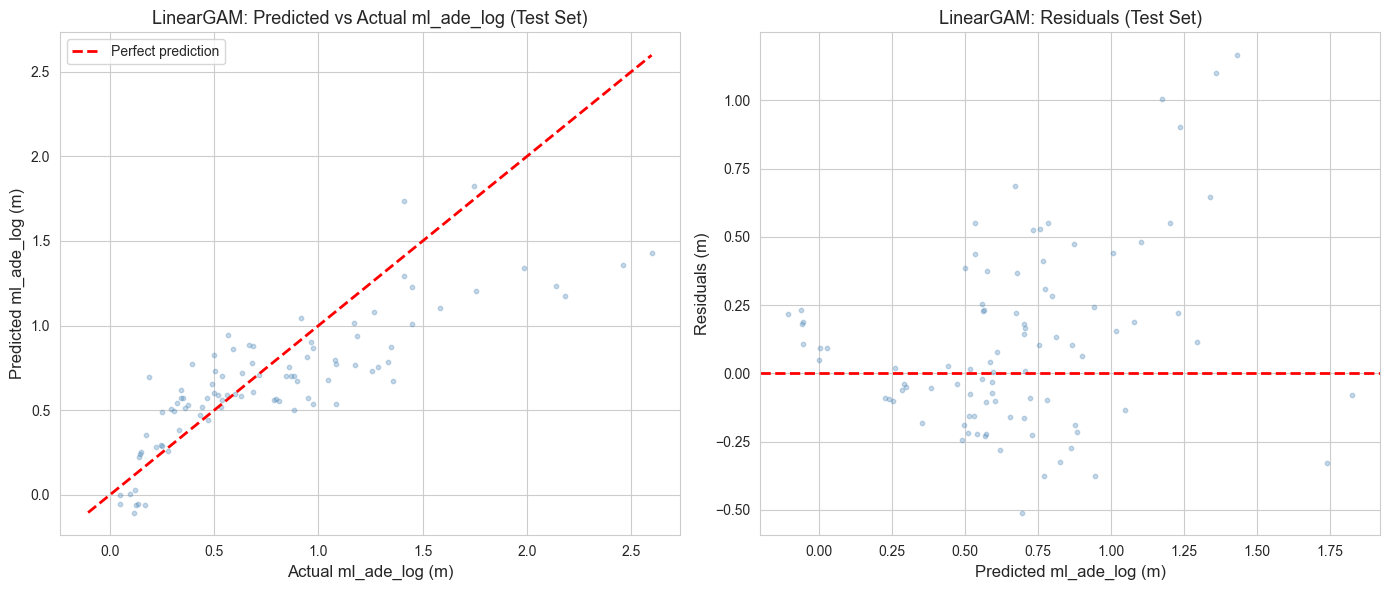

In [510]:
# Predicted vs Actual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Test set: Predicted vs Actual
axes[0].scatter(y_test_orig, y_test_pred_linear, alpha=0.3, s=10, color="steelblue")
lims = [
    min(y_test_orig.min(), y_test_pred_linear.min()),
    max(y_test_orig.max(), y_test_pred_linear.max())
]
axes[0].plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel(f"Actual {target_col} (m)", fontsize=12)
axes[0].set_ylabel(f"Predicted {target_col} (m)", fontsize=12)
axes[0].set_title(f"LinearGAM: Predicted vs Actual {target_col} (Test Set)", fontsize=13)
axes[0].legend()

# Residuals
residuals = y_test_orig - y_test_pred_linear
axes[1].scatter(y_test_pred_linear, residuals, alpha=0.3, s=10, color="steelblue")
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel(f"Predicted {target_col} (m)", fontsize=12)
axes[1].set_ylabel("Residuals (m)", fontsize=12)
axes[1].set_title("LinearGAM: Residuals (Test Set)", fontsize=13)

plt.tight_layout()
plt.savefig(SAVE_DIR / f"linear_gam_predictions_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Try Alternative GAM Setups (e.g., GammaGAM)

Fit alternative GAM models. `GammaGAM` is suitable for positive, right-skewed targets (like ADE/FDE) without requiring a log transformation.

In [511]:
# For GammaGAM, we need the original (non-log-transformed) positive target
if LOG_TRANSFORM:
    y_train_original = np.expm1(y_train)
    y_test_original = np.expm1(y_test)
else:
    y_train_original = y_train.copy()
    y_test_original = y_test.copy()

# Ensure all target values are positive (GammaGAM requirement)
positive_mask_train = y_train_original > 0
positive_mask_test = y_test_original > 0

if positive_mask_train.all() and positive_mask_test.all():
    # Build GammaGAM terms
    gamma_terms = s(0)
    for i in range(1, n_features_gam):
        gamma_terms += s(i)
    
    gamma_gam = GammaGAM(gamma_terms)
    gamma_gam.gridsearch(
        X_train_scaled[positive_mask_train], y_train_original[positive_mask_train],
        lam=np.logspace(-3, 3, 11),
        progress=False
    )
    
    print("GammaGAM Summary:")
    print("=" * 60)
    gamma_gam.summary()
    
    # Evaluate GammaGAM (predictions are already on original scale)
    y_test_pred_gamma = gamma_gam.predict(X_test_scaled[positive_mask_test])
    
    gamma_metrics = {
        "Model": "GammaGAM",
        "R² (Train)": r2_score(
            y_train_original[positive_mask_train],
            gamma_gam.predict(X_train_scaled[positive_mask_train])
        ),
        "R² (Test)": r2_score(y_test_original[positive_mask_test], y_test_pred_gamma),
        "MAE (Train)": mean_absolute_error(
            y_train_original[positive_mask_train],
            gamma_gam.predict(X_train_scaled[positive_mask_train])
        ),
        "MAE (Test)": mean_absolute_error(y_test_original[positive_mask_test], y_test_pred_gamma),
        "RMSE (Train)": np.sqrt(mean_squared_error(
            y_train_original[positive_mask_train],
            gamma_gam.predict(X_train_scaled[positive_mask_train])
        )),
        "RMSE (Test)": np.sqrt(mean_squared_error(y_test_original[positive_mask_test], y_test_pred_gamma)),
    }
    results_list.append(gamma_metrics)
else:
    print("WARNING: Target contains non-positive values (zero ADE/FDE). GammaGAM requires strictly positive targets.")
    print(f"  Non-positive in train: {(~positive_mask_train).sum()}")
    print(f"  Non-positive in test: {(~positive_mask_test).sum()}")
    print("Skipping GammaGAM fitting.")

GammaGAM Summary:
GammaGAM                                                                                                  
=============================================== ==========================================================
Distribution:                         GammaDist Effective DoF:                                     27.8269
Link Function:                          LogLink Log Likelihood:                                   -94.2011
Number of Samples:                          360 AIC:                                              246.0561
                                                AICc:                                             251.2644
                                                GCV:                                                0.2502
                                                Scale:                                              0.4462
                                                Pseudo R-Squared:                                   0.6583
Feature Function   

In [512]:
# Also try LinearGAM on original (non-transformed) target for comparison
linear_gam_orig = LinearGAM(gam_terms)
linear_gam_orig.gridsearch(
    X_train_scaled, y_train_original,
    lam=np.logspace(-3, 3, 11),
    progress=False
)

linear_orig_metrics, _, _ = evaluate_gam_model(
    linear_gam_orig, X_train_scaled, y_train_original, X_test_scaled, y_test_original,
    log_transformed=False, model_name="LinearGAM (no log)"
)
results_list.append(linear_orig_metrics)

# Comparison table
results_df = pd.DataFrame(results_list)
print("Model Comparison:")
results_df

Model Comparison:


,Model,R² (Train),R² (Test),MAE (Train),MAE (Test),RMSE (Train),RMSE (Test)
0,LinearGAM,0.678032,0.624774,0.242439,0.251221,0.333298,0.342557
1,GammaGAM,0.608612,0.658978,0.266244,0.240059,0.367476,0.326571
2,LinearGAM (no log),0.606772,0.637393,0.276078,0.259973,0.368339,0.336747


## 7. Identify and Remove Non-Significant Features

Examine p-values from the best GAM model. Identify features with p-values above a significance threshold (e.g., 0.05). Visualize partial dependence plots to understand each feature's effect on prediction error.

In [513]:
# Determine the best model based on test R²
best_model_name = results_df.loc[results_df["R² (Test)"].idxmax(), "Model"]
print(f"Best model by Test R²: {best_model_name}")

# Use the LinearGAM (log-transformed if applicable) for feature significance analysis
best_gam = linear_gam

# Extract p-values from the model
print(f"\nFeature significance analysis (from LinearGAM):")
print("=" * 60)

significance_data = []
for i, feature in enumerate(feature_cols):
    p_value = linear_gam.statistics_["p_values"][i]
    significance_data.append({
        "Feature Index": i,
        "Feature": feature,
        "p-value": p_value,
        "Significant (p < 0.05)": "✓" if p_value < 0.05 else "✗"
    })

significance_df = pd.DataFrame(significance_data).sort_values("p-value").reset_index(drop=True)
print(significance_df.to_string(index=False))

Best model by Test R²: GammaGAM

Feature significance analysis (from LinearGAM):
 Feature Index               Feature      p-value Significant (p < 0.05)
             0             max_speed 8.548529e-10                      ✓
             1             std_speed 1.271856e-09                      ✓
             2     mean_acceleration 1.981894e-04                      ✓
             5        heading_change 1.090194e-03                      ✓
             4       path_efficiency 1.170240e-03                      ✓
             3      max_acceleration 1.298210e-03                      ✓
            11 scene_spatial_density 2.645068e-01                      ✗
             8      scene_num_agents 4.784592e-01                      ✗
             7 min_neighbor_distance 5.638268e-01                      ✗
             9       scene_bbox_area 6.507342e-01                      ✗
            10      scene_bbox_width 7.008416e-01                      ✗
            12 scene_density_VEHICLE 8.5509

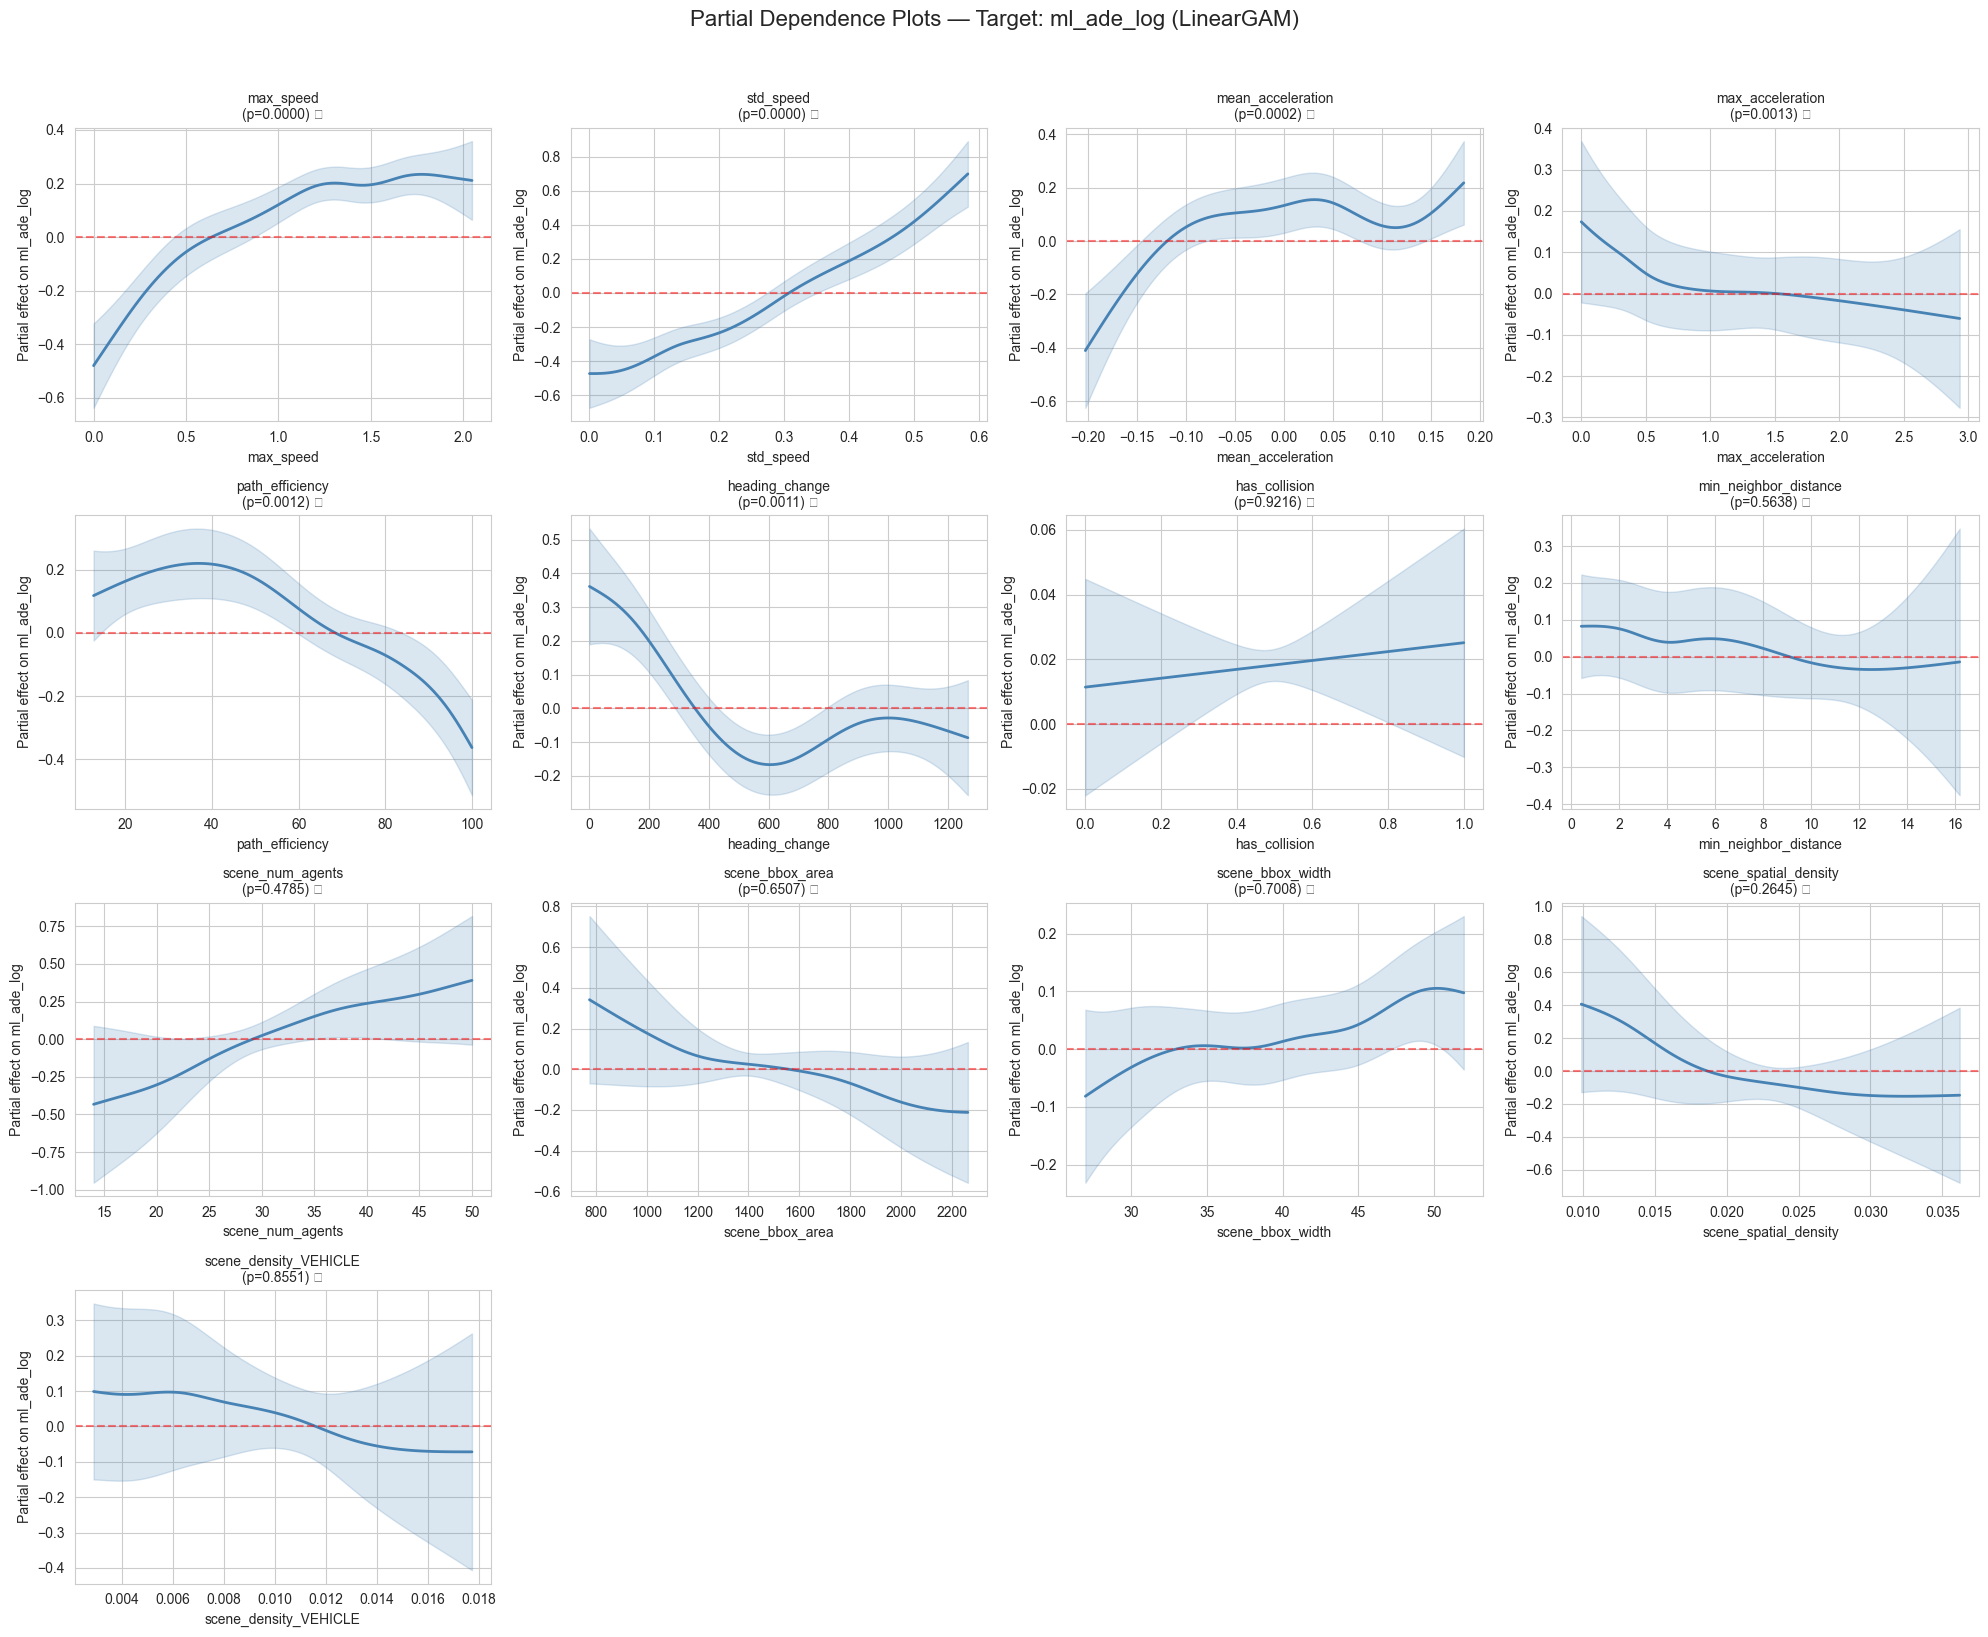

In [514]:
# Partial dependence plots for all features (x-axis in original units)
n_cols_pdp = 4
n_rows_pdp = int(np.ceil(n_features_gam / n_cols_pdp))
fig, axes = plt.subplots(n_rows_pdp, n_cols_pdp, figsize=(5 * n_cols_pdp, 4 * n_rows_pdp))
axes = axes.flatten()

for i, feature in enumerate(feature_cols):
    XX = linear_gam.generate_X_grid(term=i)
    pdep, confi = linear_gam.partial_dependence(term=i, X=XX, width=0.95)

    # Map standardized x-axis back to original scale
    x_scaled = XX[:, i]
    x_original = x_scaled * scaler.scale_[i] + scaler.mean_[i]

    axes[i].plot(x_original, pdep, color="steelblue", linewidth=2)
    axes[i].fill_between(x_original, confi[:, 0], confi[:, 1], alpha=0.2, color="steelblue")
    p_val = significance_df[significance_df["Feature"] == feature]["p-value"].values[0]
    sig_marker = "✓" if p_val < 0.05 else "✗"
    axes[i].set_title(f"{feature}\n(p={p_val:.4f}) {sig_marker}", fontsize=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(f"Partial effect on {target_col}")
    axes[i].axhline(y=0, color="red", linestyle="--", alpha=0.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Partial Dependence Plots — Target: {target_col} (LinearGAM)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / f"partial_dependence_all_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

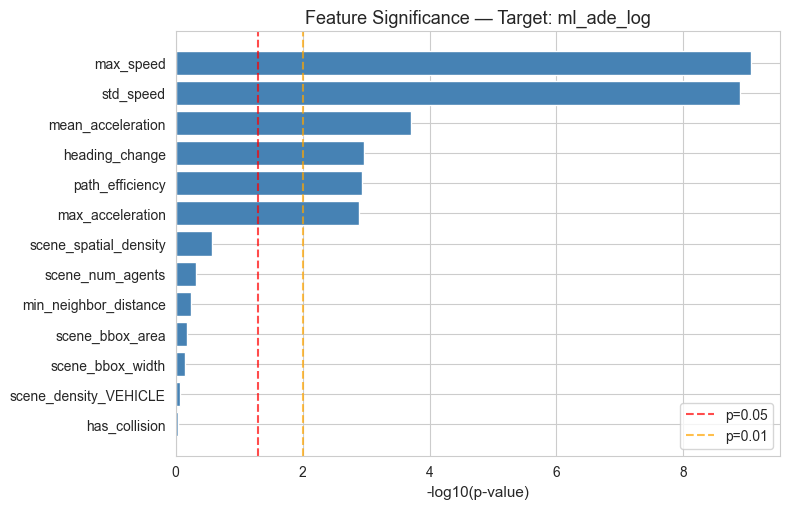

In [515]:
# Feature importance plot (-log10 p-value)
sig_sorted = significance_df.sort_values("p-value", ascending=False)
importance_vals = [-np.log10(max(p, 1e-300)) for p in sig_sorted["p-value"]]

fig, ax = plt.subplots(figsize=(8, max(4, len(feature_cols) * 0.4)))
bars = ax.barh(sig_sorted["Feature"], importance_vals, color="steelblue")
ax.axvline(x=-np.log10(0.05), color="red", linestyle="--", label="p=0.05", alpha=0.7)
ax.axvline(x=-np.log10(0.01), color="orange", linestyle="--", label="p=0.01", alpha=0.7)
ax.set_xlabel("-log10(p-value)", fontsize=11)
ax.set_title(f"Feature Significance — Target: {target_col}", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR / f"feature_significance_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

In [516]:
# Identify and remove non-significant features
SIGNIFICANCE_THRESHOLD = 0.05
significant_mask = significance_df["p-value"] < SIGNIFICANCE_THRESHOLD
significant_features = significance_df.loc[significant_mask, "Feature"].tolist()
removed_features_sig = significance_df.loc[~significant_mask, "Feature"].tolist()

print(f"Significance threshold: {SIGNIFICANCE_THRESHOLD}")
print(f"Significant features ({len(significant_features)}): {significant_features}")
print(f"Non-significant features removed ({len(removed_features_sig)}): {removed_features_sig}")

Significance threshold: 0.05
Significant features (6): ['max_speed', 'std_speed', 'mean_acceleration', 'heading_change', 'path_efficiency', 'max_acceleration']
Non-significant features removed (7): ['scene_spatial_density', 'scene_num_agents', 'min_neighbor_distance', 'scene_bbox_area', 'scene_bbox_width', 'scene_density_VEHICLE', 'has_collision']


## 8. Refit GAM on Newly Selected Features

Refit the best GAM variant using only the significant features. Re-run grid search for optimal lambda.

In [517]:
# Get indices of significant features in the original feature_cols list
sig_indices = [feature_cols.index(f) for f in significant_features]

# Subset the training and test data
X_train_sig = X_train_scaled[:, sig_indices]
X_test_sig = X_test_scaled[:, sig_indices]

print(f"Reduced feature matrix: {X_train_sig.shape[1]} features (from {X_train_scaled.shape[1]})")

# Build new GAM terms for reduced features
reduced_terms = s(0)
for i in range(1, len(sig_indices)):
    reduced_terms += s(i)

# Refit LinearGAM
linear_gam_reduced = LinearGAM(reduced_terms)
linear_gam_reduced.gridsearch(
    X_train_sig, y_train,
    lam=np.logspace(-3, 3, 11),
    progress=False
)

print("\nReduced LinearGAM Summary:")
print("=" * 60)
linear_gam_reduced.summary()

Reduced feature matrix: 6 features (from 13)

Reduced LinearGAM Summary:
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     35.8803
Link Function:                     IdentityLink Log Likelihood:                                    119.322
Number of Samples:                          360 AIC:                                             -164.8835
                                                AICc:                                            -156.2095
                                                GCV:                                                0.0405
                                                Scale:                                              0.1826
                                                Pseudo R-Squared:      

In [518]:
# Also try GammaGAM on reduced features if applicable
if positive_mask_train.all() and positive_mask_test.all():
    gamma_gam_reduced = GammaGAM(reduced_terms)
    gamma_gam_reduced.gridsearch(
        X_train_sig[positive_mask_train], y_train_original[positive_mask_train],
        lam=np.logspace(-3, 3, 11),
        progress=False
    )
    print("\nReduced GammaGAM Summary:")
    print("=" * 60)
    gamma_gam_reduced.summary()


Reduced GammaGAM Summary:
GammaGAM                                                                                                  
=============================================== ==========================================================
Distribution:                         GammaDist Effective DoF:                                      46.356
Link Function:                          LogLink Log Likelihood:                                    -72.493
Number of Samples:                          360 AIC:                                               239.698
                                                AICc:                                             254.3939
                                                GCV:                                                0.2493
                                                Scale:                                              0.4146
                                                Pseudo R-Squared:                                   0.7124
Feature Fu

## 9. Final Model Evaluation and Comparison

Evaluate the refitted models on test data. Create a comprehensive comparison table and diagnostic plots.

In [519]:
# Evaluate reduced LinearGAM
reduced_linear_metrics, y_test_orig_r, y_test_pred_reduced = evaluate_gam_model(
    linear_gam_reduced, X_train_sig, y_train, X_test_sig, y_test,
    log_transformed=LOG_TRANSFORM, model_name="LinearGAM (reduced)"
)
results_list.append(reduced_linear_metrics)

# Evaluate reduced GammaGAM if available
if positive_mask_train.all() and positive_mask_test.all():
    y_test_pred_gamma_red = gamma_gam_reduced.predict(X_test_sig[positive_mask_test])
    gamma_red_metrics = {
        "Model": "GammaGAM (reduced)",
        "R² (Train)": r2_score(
            y_train_original[positive_mask_train],
            gamma_gam_reduced.predict(X_train_sig[positive_mask_train])
        ),
        "R² (Test)": r2_score(y_test_original[positive_mask_test], y_test_pred_gamma_red),
        "MAE (Train)": mean_absolute_error(
            y_train_original[positive_mask_train],
            gamma_gam_reduced.predict(X_train_sig[positive_mask_train])
        ),
        "MAE (Test)": mean_absolute_error(y_test_original[positive_mask_test], y_test_pred_gamma_red),
        "RMSE (Train)": np.sqrt(mean_squared_error(
            y_train_original[positive_mask_train],
            gamma_gam_reduced.predict(X_train_sig[positive_mask_train])
        )),
        "RMSE (Test)": np.sqrt(mean_squared_error(y_test_original[positive_mask_test], y_test_pred_gamma_red)),
    }
    results_list.append(gamma_red_metrics)

# Final comparison table
final_results = pd.DataFrame(results_list)
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
final_results

FINAL MODEL COMPARISON


,Model,R² (Train),R² (Test),MAE (Train),MAE (Test),RMSE (Train),RMSE (Test)
0,LinearGAM,0.678032,0.624774,0.242439,0.251221,0.333298,0.342557
1,GammaGAM,0.608612,0.658978,0.266244,0.240059,0.367476,0.326571
2,LinearGAM (no log),0.606772,0.637393,0.276078,0.259973,0.368339,0.336747
3,LinearGAM (reduced),0.640603,0.586395,0.252845,0.266192,0.352138,0.359649
4,GammaGAM (reduced),0.664996,0.617765,0.243031,0.250207,0.339978,0.345741


Best Model: GammaGAM
  R² (Test):   0.6590
  MAE (Test):  0.2401 m
  RMSE (Test): 0.3266 m


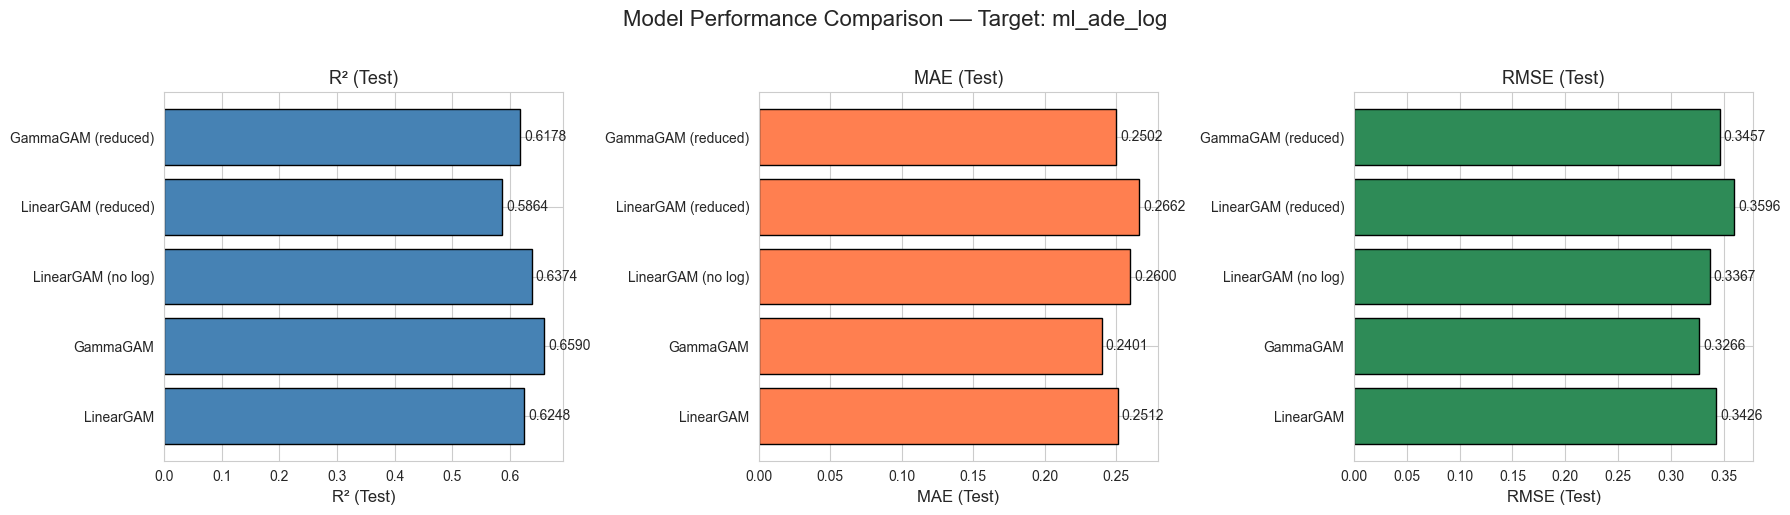

In [520]:
# Highlight the best model
best_idx = final_results["R² (Test)"].idxmax()
best_model_final = final_results.loc[best_idx]
print(f"Best Model: {best_model_final['Model']}")
print(f"  R² (Test):   {best_model_final['R² (Test)']:.4f}")
print(f"  MAE (Test):  {best_model_final['MAE (Test)']:.4f} m")
print(f"  RMSE (Test): {best_model_final['RMSE (Test)']:.4f} m")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ["R² (Test)", "MAE (Test)", "RMSE (Test)"]
colors = ["steelblue", "coral", "seagreen"]

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    bars = ax.barh(final_results["Model"], final_results[metric], color=color, edgecolor="black")
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(metric, fontsize=13)
    for bar, val in zip(bars, final_results[metric]):
        ax.text(bar.get_width() + 0.01 * abs(final_results[metric].max()), 
                bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=10)

plt.suptitle(f"Model Performance Comparison — Target: {target_col}", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / f"model_comparison_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

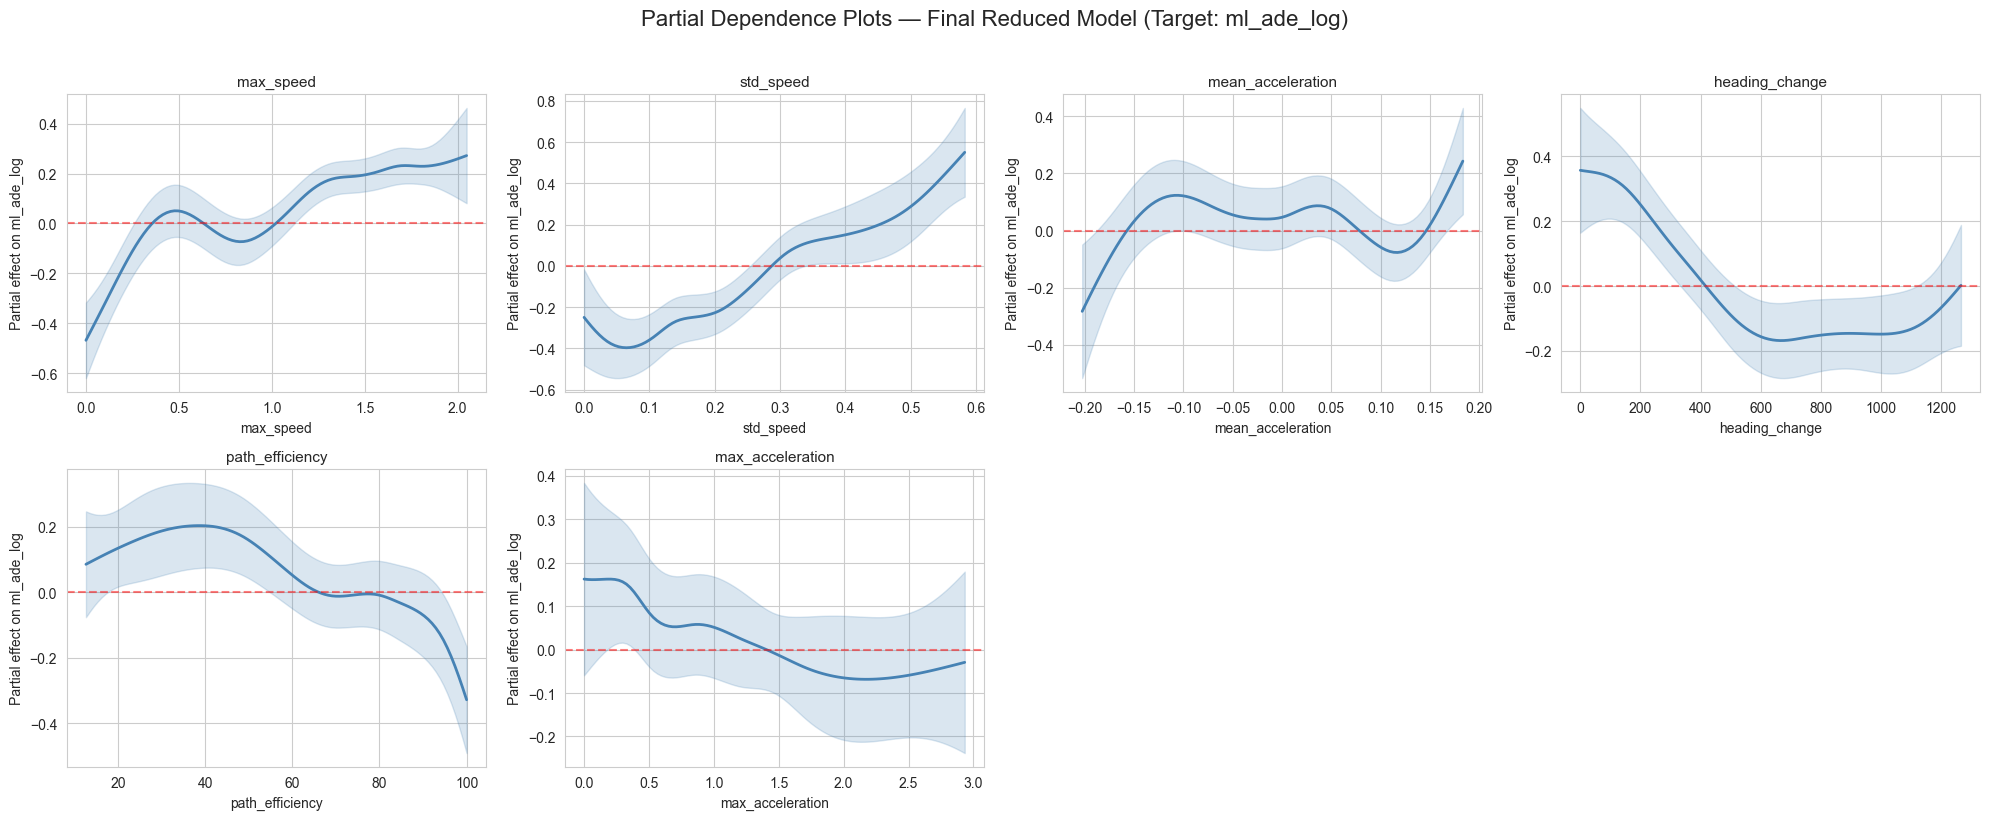

In [521]:
# Partial dependence plots for the final reduced model (x-axis in original units)
n_sig = len(significant_features)
n_cols_final = min(4, n_sig)
n_rows_final = int(np.ceil(n_sig / n_cols_final))
fig, axes = plt.subplots(n_rows_final, n_cols_final, figsize=(5 * n_cols_final, 4 * n_rows_final))
if n_sig == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for i, feature in enumerate(significant_features):
    XX = linear_gam_reduced.generate_X_grid(term=i)
    pdep, confi = linear_gam_reduced.partial_dependence(term=i, X=XX, width=0.95)

    # Map standardized x-axis back to original scale
    # sig_indices[i] maps back to the position in the original scaler
    orig_idx = sig_indices[i]
    x_scaled = XX[:, i]
    x_original = x_scaled * scaler.scale_[orig_idx] + scaler.mean_[orig_idx]

    axes[i].plot(x_original, pdep, color="steelblue", linewidth=2)
    axes[i].fill_between(x_original, confi[:, 0], confi[:, 1], alpha=0.2, color="steelblue")
    axes[i].set_title(f"{feature}", fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(f"Partial effect on {target_col}")
    axes[i].axhline(y=0, color="red", linestyle="--", alpha=0.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Partial Dependence Plots — Final Reduced Model (Target: {target_col})", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / f"partial_dependence_reduced_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

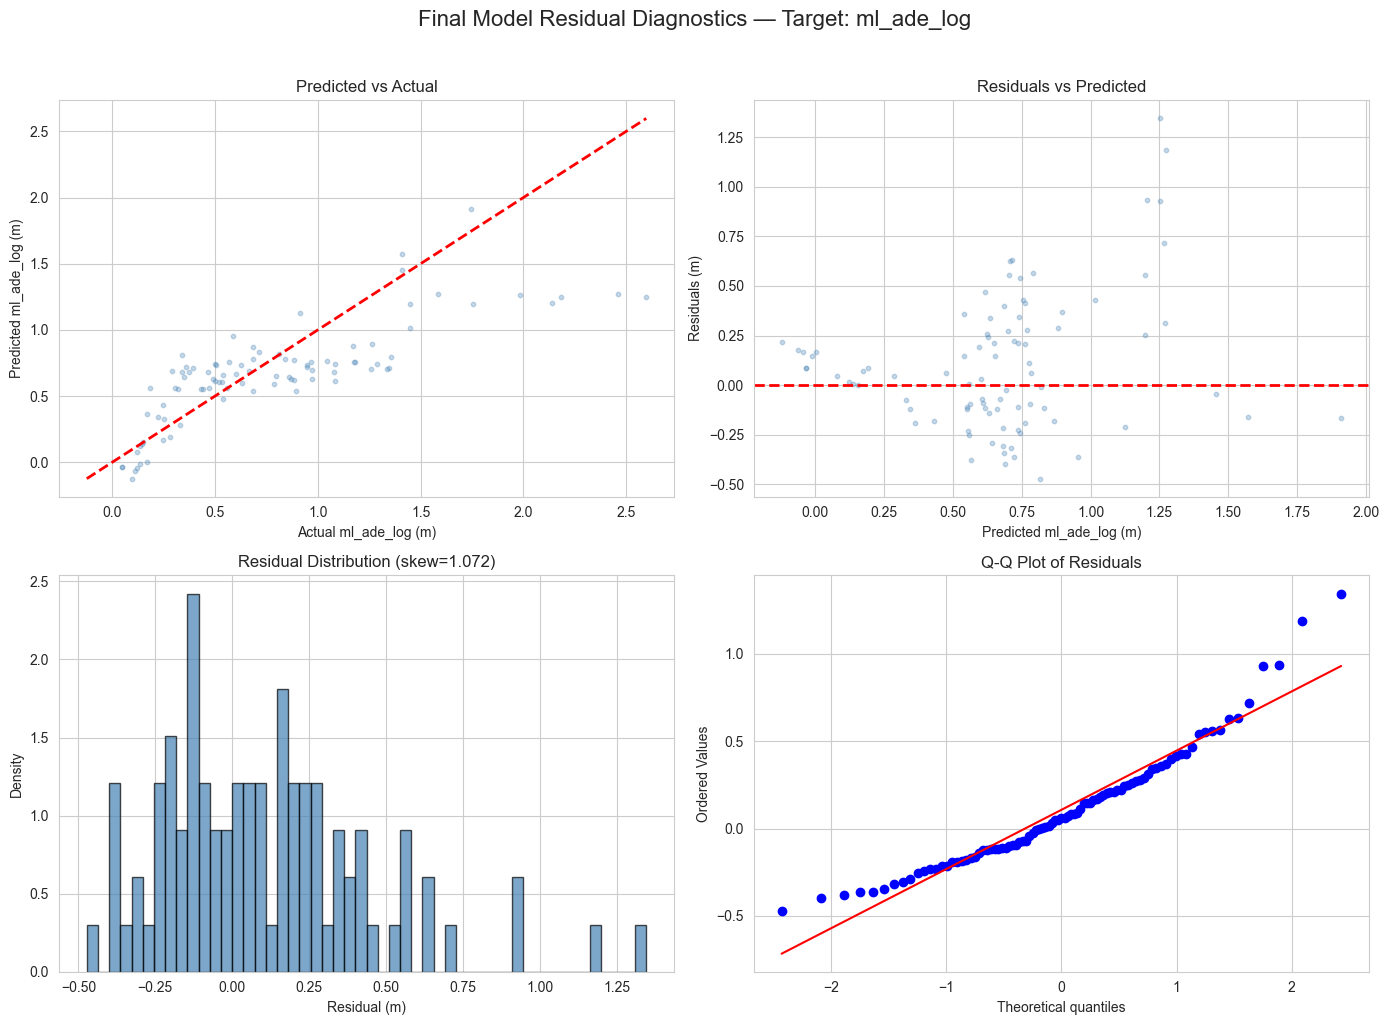


Residual statistics:
  Mean:   0.1071 m
  Std:    0.3433 m
  Median: 0.0600 m
  Skew:   1.0719


In [522]:
# Final residual diagnostics
y_final_pred = linear_gam_reduced.predict(X_test_sig)

y_final_actual = np.expm1(y_test)
y_final_pred_orig = np.expm1(y_final_pred)



residuals_final = y_final_actual - y_final_pred_orig

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Predicted vs Actual
axes[0, 0].scatter(y_final_actual, y_final_pred_orig, alpha=0.3, s=10, color="steelblue")
lims = [
    min(y_final_actual.min(), y_final_pred_orig.min()),
    max(y_final_actual.max(), y_final_pred_orig.max())
]
axes[0, 0].plot(lims, lims, "r--", linewidth=2)
axes[0, 0].set_xlabel(f"Actual {target_col} (m)")
axes[0, 0].set_ylabel(f"Predicted {target_col} (m)")
axes[0, 0].set_title("Predicted vs Actual")

# 2. Residuals vs Predicted
axes[0, 1].scatter(y_final_pred_orig, residuals_final, alpha=0.3, s=10, color="steelblue")
axes[0, 1].axhline(y=0, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel(f"Predicted {target_col} (m)")
axes[0, 1].set_ylabel("Residuals (m)")
axes[0, 1].set_title("Residuals vs Predicted")

# 3. Histogram of residuals
axes[1, 0].hist(residuals_final, bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="black")
axes[1, 0].set_xlabel("Residual (m)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title(f"Residual Distribution (skew={skew(residuals_final):.3f})")

# 4. Q-Q plot of residuals
stats.probplot(residuals_final, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of Residuals")

plt.suptitle(f"Final Model Residual Diagnostics — Target: {target_col}", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / f"residual_diagnostics_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nResidual statistics:")
print(f"  Mean:   {residuals_final.mean():.4f} m")
print(f"  Std:    {residuals_final.std():.4f} m")
print(f"  Median: {np.median(residuals_final):.4f} m")
print(f"  Skew:   {skew(residuals_final):.4f}")